In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report


In [3]:
data = pd.read_csv('seattle-weather.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [4]:
data.duplicated().sum() 

np.int64(0)

In [5]:
data['weather'].unique()

array(['drizzle', 'rain', 'sun', 'snow', 'fog'], dtype=object)

<Axes: >

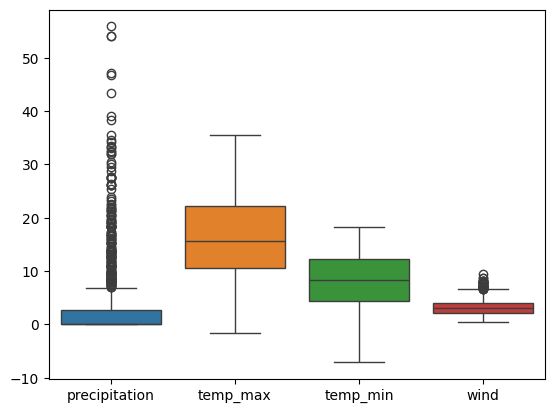

In [6]:
sns.boxplot(data=data[['date', 'precipitation', 'temp_max', 'temp_min', 'wind']])

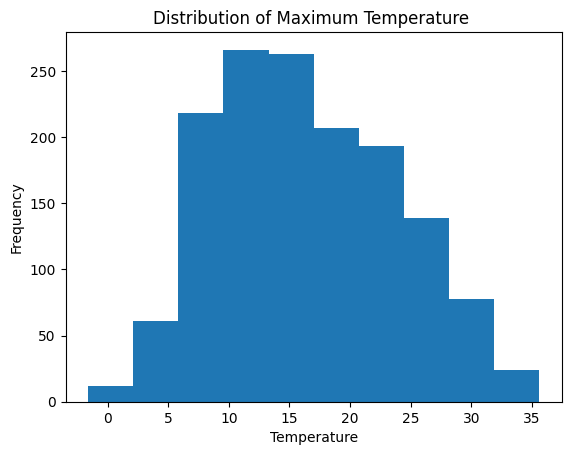

In [7]:
plt.hist(data['temp_max'])
plt.title('Distribution of Maximum Temperature ')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

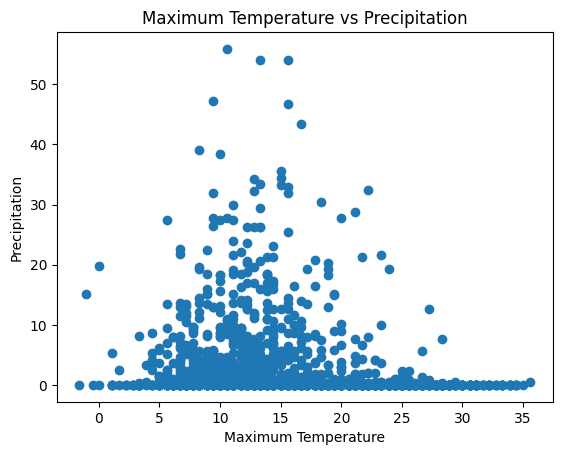

In [8]:
plt.scatter(data['temp_max'], data['precipitation'])
plt.title('Maximum Temperature vs Precipitation')
plt.xlabel('Maximum Temperature')
plt.ylabel('Precipitation')
plt.show()

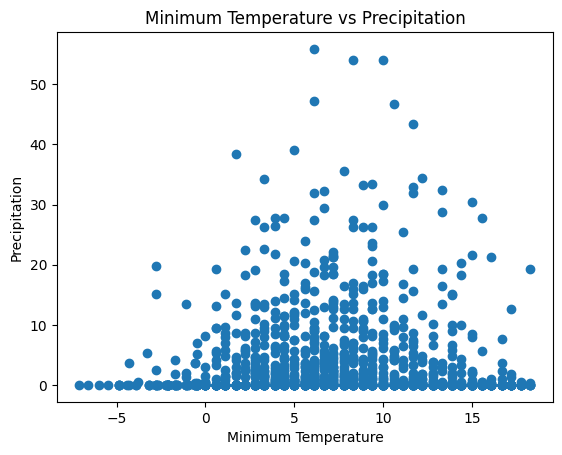

In [9]:
plt.scatter(data['temp_min'], data['precipitation'])
plt.title('Minimum Temperature vs Precipitation')
plt.xlabel('Minimum Temperature')
plt.ylabel('Precipitation')
plt.show()

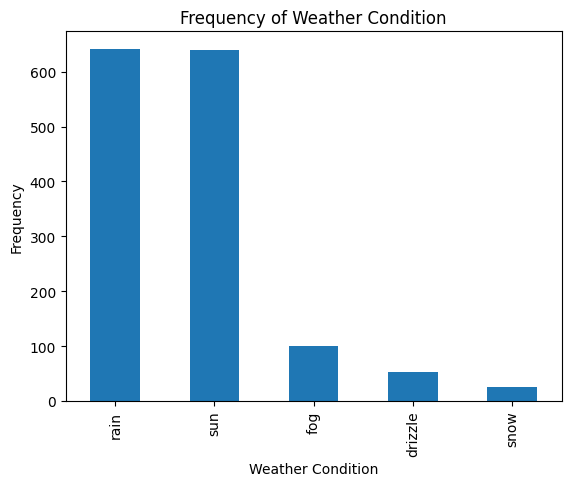

In [10]:
data['weather'].value_counts().plot(kind='bar')
plt.title('Frequency of Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Frequency')
plt.show()

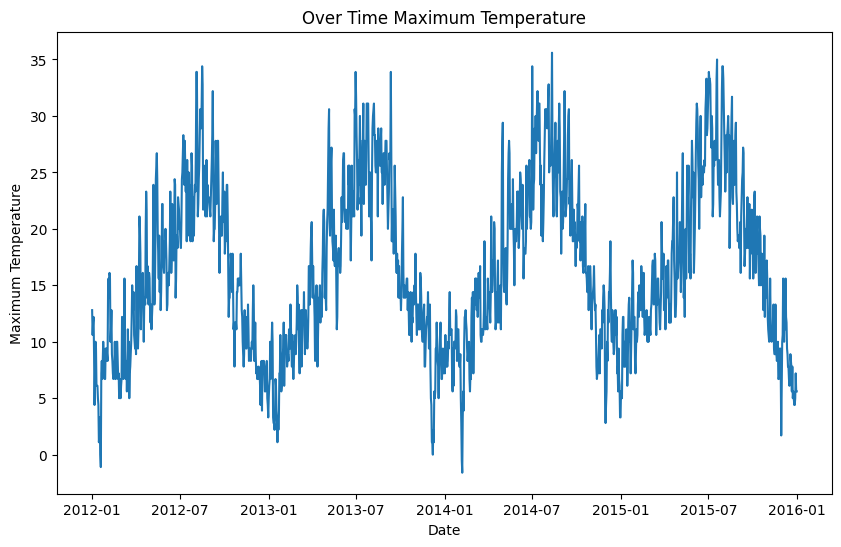

In [11]:
data['date'] = pd.to_datetime(data['date'])
plt.figure(figsize=(10,6))
plt.plot(data['date'], data['temp_max'])
plt.title('Over Time Maximum Temperature')
plt.xlabel('Date')
plt.ylabel('Maximum Temperature')

plt.show()

In [12]:
lable_Encoder = LabelEncoder()

data['weather_label'] = lable_Encoder.fit_transform(data['weather'])
data.head(10)

,date,precipitation,temp_max,temp_min,wind,weather,weather_label
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,0
1,2012-01-02,10.9,10.6,2.8,4.5,rain,2
2,2012-01-03,0.8,11.7,7.2,2.3,rain,2
3,2012-01-04,20.3,12.2,5.6,4.7,rain,2
4,2012-01-05,1.3,8.9,2.8,6.1,rain,2
5,2012-01-06,2.5,4.4,2.2,2.2,rain,2
6,2012-01-07,0.0,7.2,2.8,2.3,rain,2
7,2012-01-08,0.0,10.0,2.8,2.0,sun,4
8,2012-01-09,4.3,9.4,5.0,3.4,rain,2
9,2012-01-10,1.0,6.1,0.6,3.4,rain,2


In [13]:
weather_data = dict(zip(data['weather_label'], data['weather']))
weather_data

{0: 'drizzle', 2: 'rain', 4: 'sun', 3: 'snow', 1: 'fog'}

In [14]:
def date_and_time(data) :
    
    data['date'] = pd.to_datetime(data['date'])
    data['year'] = data['date'].dt.year 
    data['month'] = data['date'].dt.month
    data['day'] = data['date'].dt.day
    
    return data


data_final = date_and_time(data)
data_final

,date,precipitation,temp_max,temp_min,wind,weather,weather_label,year,month,day
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,0,2012,1,1
1,2012-01-02,10.9,10.6,2.8,4.5,rain,2,2012,1,2
2,2012-01-03,0.8,11.7,7.2,2.3,rain,2,2012,1,3
3,2012-01-04,20.3,12.2,5.6,4.7,rain,2,2012,1,4
4,2012-01-05,1.3,8.9,2.8,6.1,rain,2,2012,1,5
...,...,...,...,...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain,2,2015,12,27
1457,2015-12-28,1.5,5.0,1.7,1.3,rain,2,2015,12,28
1458,2015-12-29,0.0,7.2,0.6,2.6,fog,1,2015,12,29
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun,4,2015,12,30


In [15]:
data_final = data_final.drop(['weather'],axis=1).set_index('date')
data_final

,precipitation,temp_max,temp_min,wind,weather_label,year,month,day
date,,,,,,,,
2012-01-01,0.0,12.8,5.0,4.7,0,2012,1,1
2012-01-02,10.9,10.6,2.8,4.5,2,2012,1,2
2012-01-03,0.8,11.7,7.2,2.3,2,2012,1,3
2012-01-04,20.3,12.2,5.6,4.7,2,2012,1,4
2012-01-05,1.3,8.9,2.8,6.1,2,2012,1,5
...,...,...,...,...,...,...,...,...
2015-12-27,8.6,4.4,1.7,2.9,2,2015,12,27
2015-12-28,1.5,5.0,1.7,1.3,2,2015,12,28
2015-12-29,0.0,7.2,0.6,2.6,1,2015,12,29


In [16]:
X = data_final.drop(['weather_label'], axis = 1)
Y = data_final['weather_label']

over_strategy_data = {0 : 1000, 1 : 1000, 2 : 1000, 3 : 1000, 4 : 2000}
under_strategy_data = {0 : 1000, 1 : 1000, 2 : 1000, 3 : 1000, 4 : 2000}

oversampling = SMOTE(sampling_strategy = over_strategy_data)
undersampling = RandomUnderSampler(sampling_strategy = under_strategy_data)

X_Final,Y = oversampling.fit_resample(X,Y)
X_Final,Y = undersampling.fit_resample(X_Final, Y)


X_Train,X_Test,Y_Train,Y_Test = train_test_split(X_Final,Y,random_state = 32, test_size = 0.25)

In [17]:
Gaussian_NB_Model = GaussianNB()

np.random.seed(10)
Gaussian_NB_Model.fit(X_Train,Y_Train)

Prediction_Final = Gaussian_NB_Model.predict(X_Final)
Prediction_Train = Gaussian_NB_Model.predict(X_Train)
Prediction_Test = Gaussian_NB_Model.predict(X_Test)

print(f'Accuracy Score on Final Data : {round(accuracy_score(Y, Prediction_Final),2)*100}')
print(f'Accuracy Score on Training Data : {round(accuracy_score(Y_Train, Prediction_Train),2)*100}')
print(f'Accuracy Score on Testing Data : {round(accuracy_score(Y_Test, Prediction_Test),2)*100}')

Accuracy Score on Final Data : 73.0
Accuracy Score on Training Data : 73.0
Accuracy Score on Testing Data : 74.0


In [18]:
print(classification_report(Y,Prediction_Final))

              precision    recall  f1-score   support

           0       0.61      0.60      0.60      1000
           1       0.66      0.48      0.55      1000
           2       0.97      0.87      0.92      1000
           3       0.93      0.98      0.95      1000
           4       0.63      0.73      0.68      2000

    accuracy                           0.73      6000
   macro avg       0.76      0.73      0.74      6000
weighted avg       0.74      0.73      0.73      6000



In [19]:
Random_Forest_model = RandomForestClassifier()

np.random.seed(10)
Random_Forest_model.fit(X_Train, Y_Train)

Prediction_Final = Random_Forest_model.predict(X_Final)
Prediction_Train = Random_Forest_model.predict(X_Train)
Prediction_Test = Random_Forest_model.predict(X_Test)

print(f'Accuracy Score on Final Data : {round(accuracy_score(Y, Prediction_Final),2)*100}')
print(f'Accuracy Score on Training Data : {round(accuracy_score(Y_Train, Prediction_Train),2)*100}')
print(f'Accuracy Score on Testing Data : {round(accuracy_score(Y_Test, Prediction_Test),2)*100}')

Accuracy Score on Final Data : 99.0
Accuracy Score on Training Data : 100.0
Accuracy Score on Testing Data : 95.0


In [20]:
print(classification_report(Y,Prediction_Final))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1000
           1       0.99      0.96      0.98      1000
           2       1.00      0.99      0.99      1000
           3       1.00      1.00      1.00      1000
           4       0.98      0.99      0.98      2000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



In [31]:
SVC_model = SVC()

np.random.seed(10)
SVC_model.fit(X_Train, Y_Train)

Prediction_Final = SVC_model.predict(X_Final)
Prediction_Train = SVC_model.predict(X_Train)
Prediction_Test = SVC_model.predict(X_Test)

print(f'Accuracy Score on Final Data : {round(accuracy_score(Y, Prediction_Final),2)*100}')
print(f'Accuracy Score on Training Data : {round(accuracy_score(Y_Train, Prediction_Train),2)*100}')
print(f'Accuracy Score on Testing Data : {round(accuracy_score(Y_Test, Prediction_Test),2)*100}')

Accuracy Score on Final Data : 33.0
Accuracy Score on Training Data : 33.0
Accuracy Score on Testing Data : 34.0


In [32]:
print(classification_report(Y,Prediction_Final,zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.00      0.00      0.00      1000
           2       0.00      0.00      0.00      1000
           3       0.00      0.00      0.00      1000
           4       0.33      1.00      0.50      2000

    accuracy                           0.33      6000
   macro avg       0.07      0.20      0.10      6000
weighted avg       0.11      0.33      0.17      6000



In [26]:
# from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

MLP_Classifier_model = MLPClassifier()

np.random.seed(10)
MLP_Classifier_model.fit(X_Train, Y_Train)

Prediction_Final = MLP_Classifier_model.predict(X_Final)
Prediction_Train = MLP_Classifier_model.predict(X_Train)
Prediction_Test = MLP_Classifier_model.predict(X_Test)

print(f'Accuracy Score on Final Data : {round(accuracy_score(Y, Prediction_Final),2)*100}')
print(f'Accuracy Score on Training Data : {round(accuracy_score(Y_Train, Prediction_Train),2)*100}')
print(f'Accuracy Score on Testing Data : {round(accuracy_score(Y_Test, Prediction_Test),2)*100}')

Accuracy Score on Final Data : 39.0
Accuracy Score on Training Data : 39.0
Accuracy Score on Testing Data : 39.0


In [29]:
print(classification_report(Y,Prediction_Final,zero_division=0))

              precision    recall  f1-score   support

           0       0.33      0.15      0.21      1000
           1       0.22      0.88      0.36      1000
           2       1.00      0.34      0.51      1000
           3       0.77      0.98      0.86      1000
           4       0.00      0.00      0.00      2000

    accuracy                           0.39      6000
   macro avg       0.47      0.47      0.39      6000
weighted avg       0.39      0.39      0.32      6000

